In [42]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('/content/taxi_data_subset.csv')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,1,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,1,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1,23.10,2.5,0.0,0.75


In [43]:
df['tpep_pickup_datatime']=pd.to_datetime(df['tpep_pickup_datetime'])
df['hour']=df['tpep_pickup_datatime'].dt.hour
avg_tip_by_hour = df.groupby('hour')['tip_amount'].mean().round(2)
avg_tip_by_hour = avg_tip_by_hour.sort_index()
print(avg_tip_by_hour)


hour
0     3.41
1     3.35
2     3.24
3     3.27
4     3.11
5     3.40
6     3.47
7     4.10
8     3.74
9     3.65
10    3.35
11    3.34
12    3.28
13    3.31
14    3.52
15    3.79
16    3.94
17    3.85
23    0.67
Name: tip_amount, dtype: float64


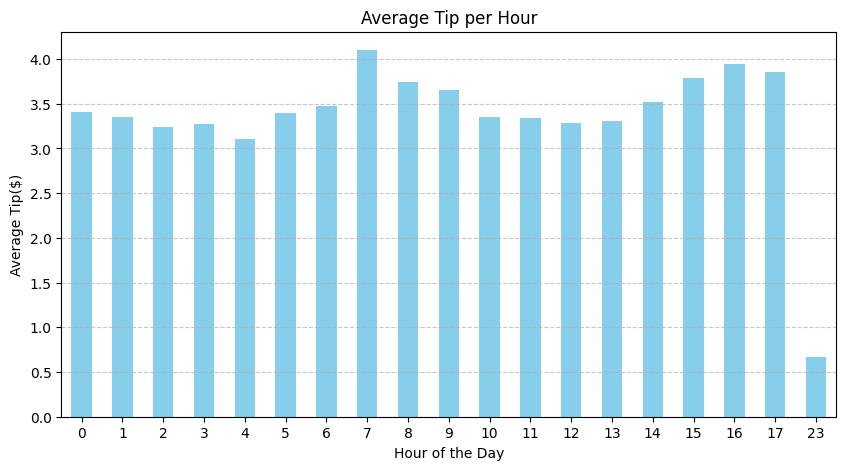

In [44]:
plt.figure(figsize=(10,5))
avg_tip_by_hour.plot(kind='bar',color='skyblue')

plt.title('Average Tip per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Tip($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--',alpha=0.7)
plt.show()

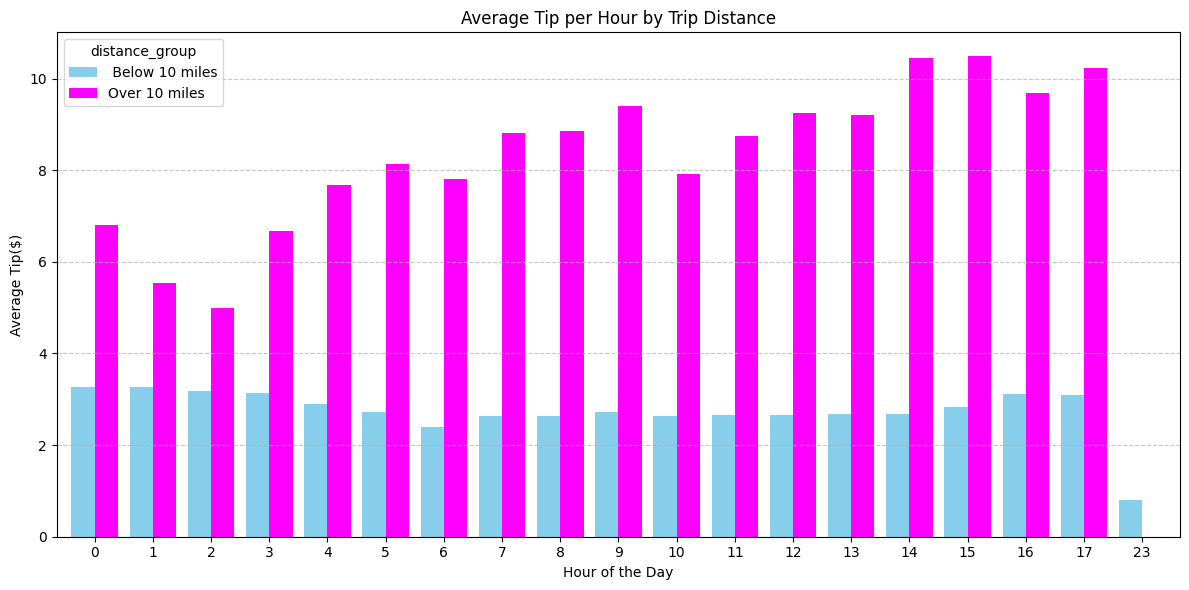

In [45]:
df['distance_group']=df['trip_distance'].apply(
      lambda x: "Over 10 miles" if x >=10 else " Below 10 miles")

df['hour']=df['tpep_pickup_datatime'].dt.hour
hourly_tips = (df.groupby(['hour','distance_group'])['tip_amount'].mean().unstack(fill_value=0))
ax=hourly_tips.plot(kind='bar',figsize=(12,6),color=['skyblue','magenta'],width=0.8)

plt.title('Average Tip per Hour by Trip Distance')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Tip($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()